<a href="https://colab.research.google.com/github/hemchan-cyber/M.tech-AI-3rd-sem-practical-projects/blob/main/Email_Spam_Classification_Comparative_Analysis_of_ML_%26_DL_Approaches.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Email Spam Classification: Comparative Analysis of ML & DL Approaches**
##**1. Project Overview & Objective**
This project implements an end-to-end Natural Language Processing (NLP) pipeline to classify incoming emails into Ham (Legitimate) or Spam (Malicious/Unsolicited).

To determine the most effective architecture for production deployment, three distinct modeling paradigms are benchmarked against the same dataset:
1.   Multinomial Naive Bayes (MNB) — Baseline Probabilistic Classifier.
2.   Linear Support Vector Classifier (LinearSVC) — Geometric / Maximum Margin Classifier.
3.   Bidirectional Long Short-Term Memory (BiLSTM) — Recurrent Deep Learning Architecture
##**2. End-to-End Pipeline Architecture**
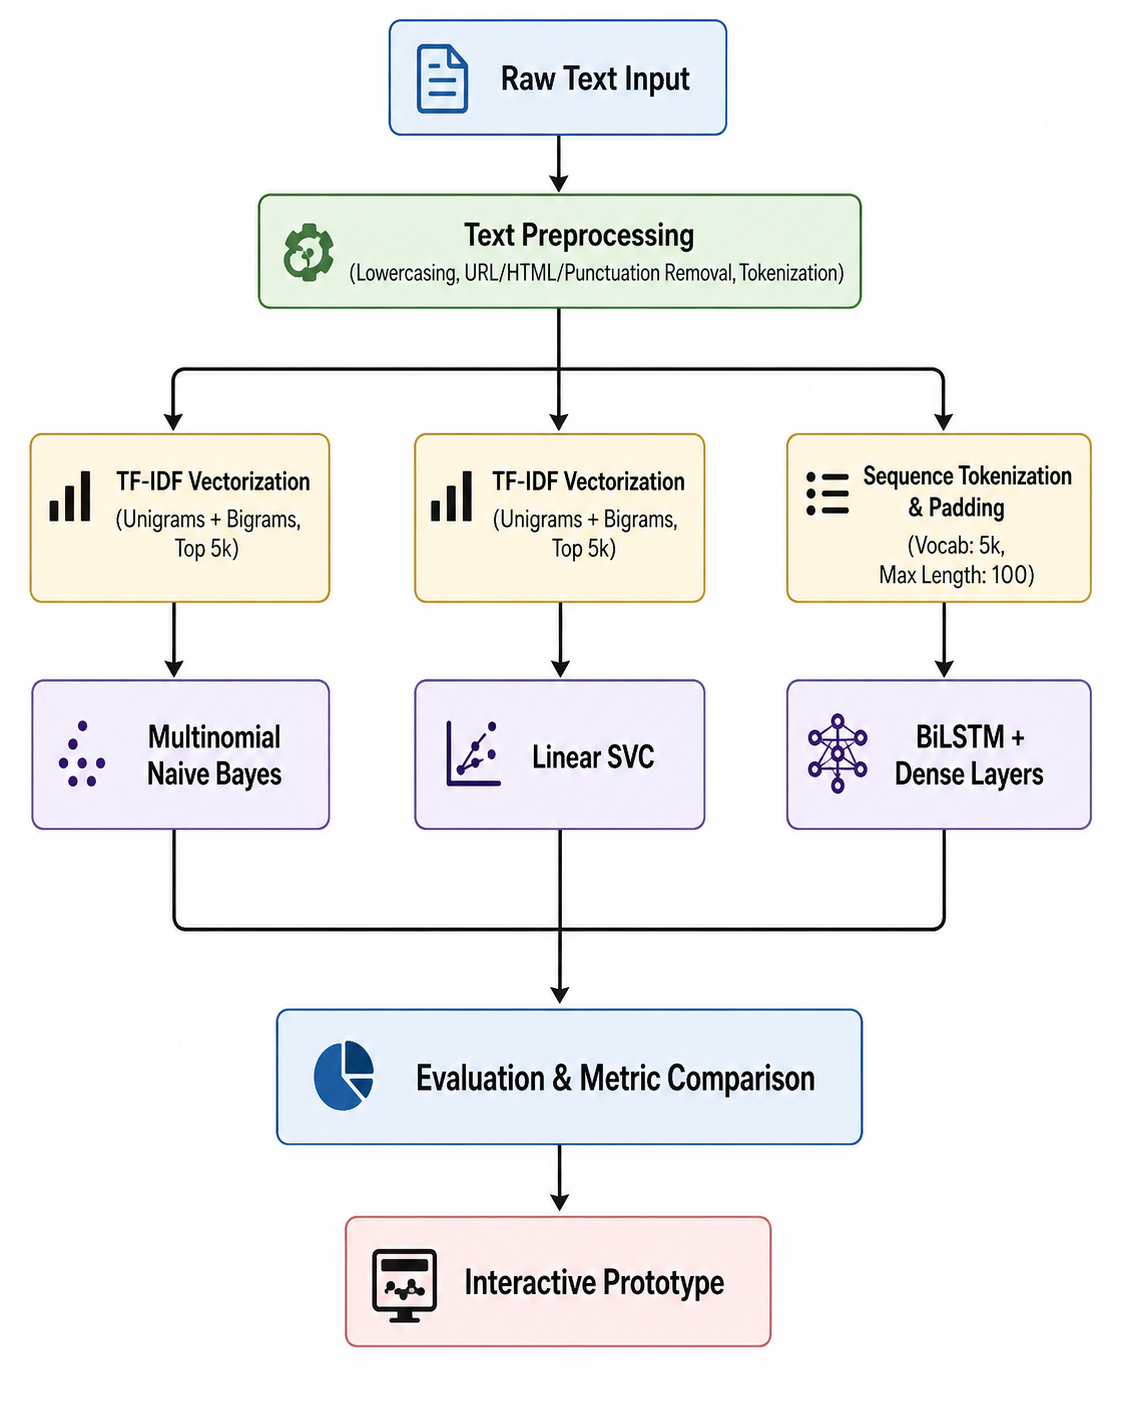

## a) SETUP & DEPENDENCIES

In [ ]:
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,confusion_matrix, classification_report, roc_curve, auc)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, SpatialDropout1D
# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## b) DATA LOADING & PREPROCESSING

In [ ]:
# 1. Loading the dataset
df = pd.read_csv('combined_data.csv')
# Drop missing values if any
df = df.dropna()

In [ ]:
# Checking what columns are actually named
print("Columns in combined_data.csv:", df.columns.tolist())

Columns in combined_data.csv: ['label', 'text']


In [ ]:
# 2. Cleaning the text
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)

In [ ]:
# 3. Creating the Train-Test Split (This creates X_train_raw!)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['clean_text'], df['label'], test_size=0.20, random_state=42, stratify=df['label']
)

print("Data successfully loaded and split! You can now run Step 3.")

Data successfully loaded and split! You can now run Step 3.


## c) FEATURE EXTRACTION (TF-IDF for ML)

In [ ]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf = tfidf.transform(X_test_raw)

#**3. Detailed Model Analysis**
##Model 1: Multinomial Naive Bayes (MNB)Underlying Theory:
MNB applies Bayes' Theorem under the strong ("naive") assumption of conditional independence between every pair of features (words) given the class label:$$P(c \mid d) \propto P(c) \prod_{i=1}^{n} P(w_i \mid c)$$Feature Representation: Bag-of-Words / TF-IDF sparse matrix.Strengths:Extremely fast training and evaluation with near-zero compute overhead.Robust against high feature dimensionality relative to sample size.Requires very little memory, making it ideal for edge devices.Limitations:Ignores word order, phrases, and semantic context.Over-penalizes unseen words during inference (mitigated via Laplace smoothing $\alpha$).
##Model 2: Linear Support Vector Classifier (LinearSVC)Underlying Theory:
LinearSVC finds the optimal hyperplane that separates the two classes with the maximum possible margin in high-dimensional feature space. It minimizes the hinge loss with L2 regularization:$$\min_{w, b} \frac{1}{2} \Vert{}w\Vert{}^2 + C \sum_{i=1}^{N} \max\left(0, 1 - y_i (w \cdot x_i + b)\right)$$Feature Representation: Sparse TF-IDF representations with n-gram ranges $(1, 2)$.Strengths:Highly effective in high-dimensional text spaces where boundary separation is linear.Resilient to overfitting when regularized properly (controlled by parameter $C$).Delivers high classification precision on short and medium-length messages.Limitations:Produces raw decision scores rather than well-calibrated class probabilities natively.Sensitivity to feature scaling and extreme outliers.
##Model 3: Deep Learning — Bidirectional LSTM (BiLSTM)Underlying Theory:
BiLSTMs process token sequences in both forward and backward directions using gating mechanisms (input, forget, and output gates) to retain long-range contextual dependencies:$$\vec{h}_t = \text{LSTM}(x_t, \vec{h}_{t-1}), \quad \overleftarrow{h}_t = \text{LSTM}(x_t, \overleftarrow{h}_{t+1}), \quad h_t = [\vec{h}_t \,\Vert{}\, \overleftarrow{h}_t]$$Architecture Pipeline:Embedding Layer: Projects discrete token indices into dense continuous vector space.Spatial Dropout: Drops entire 1D feature maps to prevent co-adaptation of words.Bidirectional LSTM Layer: Captures semantic context from past and future tokens.Dense + Dropout + Sigmoid: Performs binary classification with non-linear mapping.Strengths:Understands word order, contextual triggers, and conversational nuance.Does not rely on manual feature engineering or static n-gram dictionaries.Limitations:Higher computational complexity and training time (requires GPU acceleration).Risk of overfitting on smaller tabular datasets without sufficient regularization.

## d) MODEL 1: MULTINOMIAL NAIVE BAYES

In [ ]:
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_tfidf, y_train)
nb_preds = nb_model.predict(X_test_tfidf)
nb_probs = nb_model.predict_proba(X_test_tfidf)[:, 1]

## e) MODEL 2: LINEAR SVC

In [ ]:
svc_model = LinearSVC(C=1.0, random_state=42)
svc_model.fit(X_train_tfidf, y_train)
svc_preds = svc_model.predict(X_test_tfidf)
svc_scores = svc_model.decision_function(X_test_tfidf) # Distance for ROC

## f) MODEL 3: DEEP LEARNING (BiLSTM)

In [ ]:
MAX_VOCAB_SIZE = 5000
MAX_SEQ_LENGTH = 100
EMBEDDING_DIM = 64

tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_raw)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train_raw), maxlen=MAX_SEQ_LENGTH, padding='post', truncating='post')
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test_raw), maxlen=MAX_SEQ_LENGTH, padding='post', truncating='post')

dl_model = Sequential([
    Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_SEQ_LENGTH),
    SpatialDropout1D(0.2),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

dl_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
# Training the DL model
history = dl_model.fit(
    X_train_seq, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

dl_probs = dl_model.predict(X_test_seq).ravel()
dl_preds = (dl_probs >= 0.5).astype(int)

Epoch 1/5
366/366 ━━━━━━━━━━━━━━━━━━━━ 47s 101ms/step - accuracy: 0.9178 - loss: 0.2012 - val_accuracy: 0.9661 - val_loss: 0.0936
Epoch 2/5
366/366 ━━━━━━━━━━━━━━━━━━━━ 36s 97ms/step - accuracy: 0.9764 - loss: 0.0692 - val_accuracy: 0.9723 - val_loss: 0.0919
Epoch 3/5
366/366 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.9875 - loss: 0.0358 - val_accuracy: 0.9692 - val_loss: 0.1115
Epoch 4/5
366/366 ━━━━━━━━━━━━━━━━━━━━ 43s 102ms/step - accuracy: 0.9920 - loss: 0.0259 - val_accuracy: 0.9731 - val_loss: 0.0995
Epoch 5/5
366/366 ━━━━━━━━━━━━━━━━━━━━ 35s 96ms/step - accuracy: 0.9925 - loss: 0.0249 - val_accuracy: 0.9692 - val_loss: 0.1218
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step


#4. Technical Trade-Offs & Architecture Comparison
| Evaluation Dimension | Multinomial Naive Bayes | Linear SVC | Bidirectional LSTM |
| :--- | :--- | :--- | :--- |
| **Input Format** | Sparse TF-IDF Vector | Sparse TF-IDF Vector | Dense Token Sequence |
| **Feature Extraction** | Frequency / Statistics | Frequency / Statistics | Learned Embeddings |
| **Training Speed** | Near Instantaneous (< 1s) | Very Fast (< 2s) | Moderate (Epoch-dependent) |
| **Inference Latency** | Ultra Low (< 1ms) | Ultra Low (< 1ms) | Low (5 - 15ms) |
| **Context Retention** | None (Bag of Words) | Limited (N-grams) | High (Bidirectional state) |
| **Memory Footprint** | Minimal (< 5 MB) | Low (< 10 MB) | Moderate (20 - 50 MB) |
| **Interpretability** | High (Feature log-probs) | High (Feature weights) | Low (Black-box gates) |

## g) PERFORMANCE COMPARISON & METRICS

In [ ]:
models = ['Multinomial NB', 'Linear SVC', 'BiLSTM']
predictions = [nb_preds, svc_preds, dl_preds]
probabilities = [nb_probs, svc_scores, dl_probs]

results = []
for name, y_pred in zip(models, predictions):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})

results_df = pd.DataFrame(results)
print("\n--- Summary Performance Table ---")
print(results_df.to_string(index=False))


--- Summary Performance Table ---
         Model  Accuracy  Precision   Recall  F1-Score
Multinomial NB  0.957820   0.956421 0.963700  0.960047
    Linear SVC  0.979064   0.973441 0.987119  0.980233
        BiLSTM  0.966749   0.955581 0.982436  0.968822


#**5. Evaluation Strategy & Metrics**
##Key Metrics Tracked
*   Accuracy: Overall proportion of correctly identified emails.
*   Precision: Ratio of true spam among all emails flagged as spam.
*   Recall: Ratio of actual spam emails successfully caught.
*   F1-Score: Harmonic mean of precision and recall.
*   ROC-AUC: Diagnostic ability across variable classification thresholds.
##Engineering Note on Precision vs. Recall:

In spam classification, False Positives (marking a critical legitimate email as spam) are significantly more harmful than False Negatives (letting a spam email reach the inbox). Consequently, models with higher Precision and high F1-Score are prioritized over models that only maximize raw accuracy.

## h) VISUALIZATIONS & GRAPHS

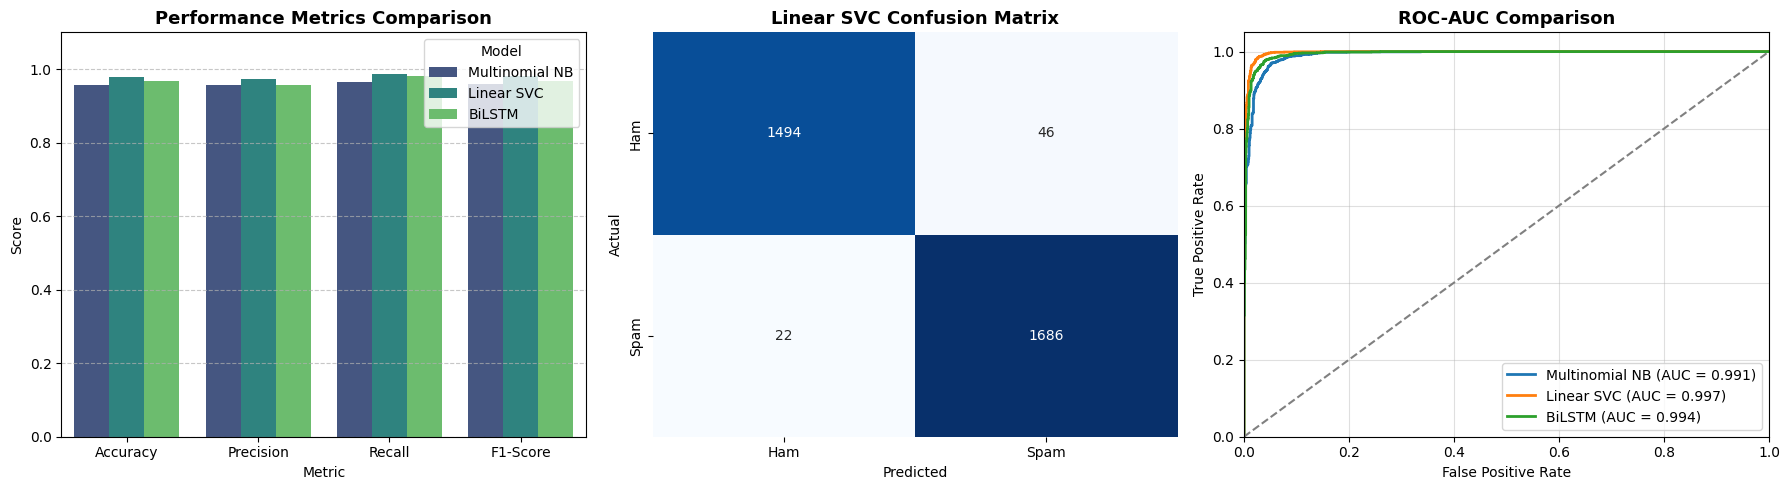

In [ ]:
plt.figure(figsize=(18, 5))

# Plot 1: Metric Comparison Bar Chart
plt.subplot(1, 3, 1)
df_melted = pd.melt(results_df, id_vars='Model', var_name='Metric', value_name='Score')
sns.barplot(data=df_melted, x='Metric', y='Score', hue='Model', palette='viridis')
plt.title('Performance Metrics Comparison', fontsize=13, fontweight='bold')
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Plot 2: Confusion Matrices
plt.subplot(1, 3, 2)
cm_svc = confusion_matrix(y_test, svc_preds)
sns.heatmap(cm_svc, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Linear SVC Confusion Matrix', fontsize=13, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Plot 3: ROC Curves
plt.subplot(1, 3, 3)
for name, y_prob in zip(models, probabilities):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Comparison', fontsize=13, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.4)

plt.tight_layout()
plt.show()

#Automatic Champion Model Selection & Export

In [ ]:
import joblib

# Determining the best traditional ML model by F1-Score
best_ml_idx = np.argmax([results[0]['F1-Score'], results[1]['F1-Score']])
best_ml_name = models[best_ml_idx]
best_ml_model = [nb_model, svc_model][best_ml_idx]

print(f"Top Machine Learning Model: {best_ml_name}")
print(f"Deep Learning (BiLSTM) F1-Score: {results[2]['F1-Score']:.4f}")

# Saving the Vectorizer and the Top ML Model
joblib.dump(tfidf, 'tfidf_vectorizer.joblib')
joblib.dump(best_ml_model, 'best_spam_model.joblib')
print("Model and vectorizer successfully saved to disk!")

Top Machine Learning Model: Linear SVC
Deep Learning (BiLSTM) F1-Score: 0.9688
Model and vectorizer successfully saved to disk!


#Prediction Pipeline Function

In [ ]:
def classify_email(raw_text, model=best_ml_model, vectorizer=tfidf):
    # 1. Cleaning input
    cleaned = clean_text(raw_text)

    # 2. Vectorizing
    vec = vectorizer.transform([cleaned])

    # 3. Predicting & Confidence
    pred = model.predict(vec)[0]

    # Calculating confidence score
    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(vec)[0][pred] * 100
    elif hasattr(model, "decision_function"):
        # Converting decision function distance to pseudo-probability via sigmoid
        dist = model.decision_function(vec)[0]
        prob = (1 / (1 + np.exp(-abs(dist)))) * 100
    else:
        prob = 100.0

    label = "SPAM" if pred == 1 else "HAM (Legitimate)"
    return label, prob

#Interactive Colab Prototype (ipywidgets)

In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# Creating UI Elements
title_html = widgets.HTML("<h3> Email Spam Detection Prototype</h3><p>Enter an email message below to classify it in real time.</p>")

sample_emails = {
    "Select a pre-set sample...": "",
    "Bank Alert (Spam)": "URGENT! Your debit card has been locked. Verify your credentials immediately at http://secure-bank-login.com to claim $500 cash reward.",
    "Meeting Reminder (Ham)": "Hi team, let us review the sprint retrospective meeting tomorrow at 10:00 AM in Conference Room B.",
    "Lottery Winner (Spam)": "CONGRATULATIONS! You have won $1,000,000 in the UK International Lottery. Reply with your passport details to claim.",
    "Project Follow-up (Ham)": "Please find attached the updated slides for our project proposal. Let me know if you need any adjustments."
}

dropdown = widgets.Dropdown(
    options=list(sample_emails.keys()),
    description='Samples:',
    layout=widgets.Layout(width='600px')
)

text_input = widgets.Textarea(
    value='',
    placeholder='Type or paste the email subject & body here...',
    layout=widgets.Layout(width='600px', height='140px')
)

classify_btn = widgets.Button(
    description='Classify Email',
    button_style='primary',
    tooltip='Run Spam Detection',
    icon='search'
)

output_area = widgets.Output()

def on_dropdown_change(change):
    if change['new'] in sample_emails:
        text_input.value = sample_emails[change['new']]

dropdown.observe(on_dropdown_change, names='value')

def on_button_clicked(b):
    with output_area:
        clear_output()
        raw_text = text_input.value.strip()
        if not raw_text:
            display(HTML("<p style='color: orange; font-weight: bold;'>⚠️ Please enter some email text to analyze.</p>"))
            return

        label, conf = classify_email(raw_text)

        # Styling output badge
        bg_color = "#ffebee" if "SPAM" in label else "#e8f5e9"
        border_color = "#d32f2f" if "SPAM" in label else "#388e3c"
        text_color = "#c62828" if "SPAM" in label else "#2e7d32"
        icon = "🚨" if "SPAM" in label else "✅"

        result_html = f"""
        <div style="border: 2px solid {border_color}; background-color: {bg_color}; padding: 15px; border-radius: 8px; width: 570px; margin-top: 10px;">
            <h4 style="margin: 0; color: {text_color}; font-size: 18px;">{icon} Classification: {label}</h4>
            <p style="margin: 8px 0 0 0; color: #333;"><strong>Model Confidence:</strong> {conf:.2f}%</p>
        </div>
        """
        display(HTML(result_html))

classify_btn.on_click(on_button_clicked)

# Rendering UI layout
ui = widgets.VBox([title_html, dropdown, text_input, classify_btn, output_area])
display(ui)

#**6. Inference & Interactive Demonstration**
The final pipeline exports the trained champion model along with its vectorization artifacts. The prototype interface:



*   Accepts raw, unformatted email subject lines and body text.
*   Applies standard regex sanitization (stripping URLs, punctuation, and numeric noise).
*   Evaluates real-time classification along with confidence scoring.









#Alternative Shareable Web App (Gradio)

In [ ]:
!pip install gradio -q
import gradio as gr

def gradio_predict(email_content):
    if not email_content.strip():
        return "Please provide email text.", "0%"
    label, conf = classify_email(email_content)
    return label, f"{conf:.2f}%"

demo = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Textbox(lines=6, placeholder="Paste email content here...", label="Email Text"),
    outputs=[
        gr.Label(label="Prediction"),
        gr.Textbox(label="Confidence")
    ],
    title="Email Spam Classifier",
    description="Interactive demonstration using the trained NLP classification pipeline.",
    examples=[
        ["WINNER! You have won a guaranteed £1000 prize. Call 09064018831 to claim now."],
        ["Hey, are we still meeting up for coffee this afternoon? Let me know!"]
    ]
)

# Set share=True to generate a temporary public link
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e3d84a29953b8b7f57.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


#Testing sample
##Option 1: Legitimate Email (Ham)
###You can use this to verify that your model correctly identifies normal, everyday communication without flagging it falsely.

##Subject: Assignment details for Data Mining and Warehousing
##Body:

Hi Hemchandra,

I've attached the reference materials for our upcoming Data Mining and Warehousing lecture. Please review the section on Apache Hive and MapReduce before tomorrow's class.

Also, let me know if you will be around Room 106 later this evening. We still need to finalize the Google Sheets API integration for the AttendanceX tracker before the weekend.

See you tomorrow,
Rahul

##Option 2: Malicious Email (Spam)
###You can use this to test if your model successfully catches urgent, manipulative language and suspicious links.

##Subject: URGENT: Your AI Research Grant of $10,000 is pending!
##Body:

CONGRATULATIONS!!!

Your recent academic profile has been randomly selected from our international database to receive a guaranteed cash grant of $10,000 for your Artificial Intelligence research!

This is a ONE-TIME offer and your funds will be forfeited if not claimed within 24 hours. URGENT: Click here immediately http://secure-grant-claim-award.info/login to verify your bank account credentials and receive your money.

100% FREE! Act now!